# Data Preprocessing

This notebook prepares the bankruptcy dataset for machine learning by:

- Handling missing values
- Treating extreme outliers
- Selecting informative features
- Preparing the dataset for modeling

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

%matplotlib inline

# Load Dataset

In [2]:
DATA_PATH = "../data/bankruptcy.csv"

df = pd.read_csv(DATA_PATH)

df = df.rename(
    columns={
        "class": "Bankrupt"
    }
)

print(df.shape)

df.head()

(43405, 66)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16,A17,A18,A19,A20,A21,A22,A23,A24,A25,A26,A27,A28,A29,A30,A31,A32,A33,A34,A35,A36,A37,A38,A39,A40,A41,A42,A43,A44,A45,A46,A47,A48,A49,A50,A51,A52,A53,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63,A64,Bankrupt,year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,0.249760,0.65980,0.166600,0.249760,497.42,0.73378,2.6349,0.249760,0.149420,43.370,1.2479,0.21402,0.119980,0.47706,0.50494,0.60411,1.45820,1.7615,5.9443,0.11788,0.149420,94.14,3.8772,0.56393,0.21402,1.7410,593.2700,0.50591,0.128040,0.662950,0.051402,0.128040,114.42,71.050,1.00970,1.52250,49.394,0.185300,0.110850,2.0420,0.37854,0.25792,2.2437,2.2480,348690.0,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,0.261140,0.51680,0.158350,0.258340,677.96,0.53838,2.0005,0.258340,0.152000,87.981,1.4293,0.24806,0.123040,NaN,0.39542,0.43992,88.44400,16.9460,3.6884,0.26969,0.152000,122.17,2.9876,2.98760,0.20616,1.6996,NaN,0.49788,0.121300,0.086422,0.064371,0.145950,199.49,111.510,0.51045,1.12520,100.130,0.237270,0.139610,1.9447,0.49988,0.33472,17.8660,17.8660,2304.6,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,0.312580,0.64184,0.244350,0.309060,794.16,0.45961,1.4369,0.309060,0.236100,73.133,1.4283,0.30260,0.189960,NaN,0.28932,0.37282,86.01100,1.0627,4.3749,0.41929,0.238150,176.93,2.0630,1.42740,0.31565,1.3090,2.3019,0.51537,0.241140,0.322020,0.074020,0.231170,165.51,92.381,0.94807,1.01010,96.372,0.291810,0.222930,1.0758,0.48152,0.48474,1.2098,2.0504,6332.7,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,0.092704,0.30163,0.094257,0.092704,917.01,0.39803,3.2537,0.092704,0.071428,79.788,1.5069,0.11550,0.062782,0.17193,0.57353,0.36152,0.94076,1.9618,4.6511,0.14343,0.071428,91.37,3.9948,0.37581,0.11550,1.3562,NaN,0.57353,0.088995,0.401390,0.069622,0.088995,180.77,100.980,0.28720,1.56960,84.344,0.085874,0.066165,2.4928,0.30734,0.25033,2.4524,2.4524,20545.0,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,0.187320,0.33147,0.121820,0.187320,1133.20,0.32211,1.6307,0.187320,0.115530,57.045,NaN,0.19832,0.115530,0.18732,0.38677,0.32211,1.41380,1.1184,4.1424,0.27884,0.115530,147.04,2.4823,0.32340,0.19832,1.6278,11.2470,0.43489,0.122310,0.293040,0.096680,0.122310,141.62,84.574,0.73919,0.95787,65.936,0.188110,0.116010,1.2959,0.56511,0.40285,1.8839,2.1184,3186.6,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,1


# Missing Value Analysis

In [3]:
missing_summary = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_summary[
    missing_summary > 0
].head(20)

A37    18984
A21     5854
A27     2764
A60     2152
A45     2147
A24      922
A64      812
A53      812
A28      812
A54      812
A41      754
A32      368
A52      301
A47      297
A46      135
A4       134
A33      134
A40      134
A12      134
A63      134
dtype: int64

# Missing Value Imputation

In [4]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

imputer = SimpleImputer(
    strategy="median"
)

df[numeric_cols] = imputer.fit_transform(
    df[numeric_cols]
)

print(
    "Remaining Missing Values:",
    df.isnull().sum().sum()
)

Remaining Missing Values: 0


# Outlier Treatment

In [5]:
def cap_outliers(
    dataframe,
    lower=0.01,
    upper=0.99
):
    df_copy = dataframe.copy()

    numeric_columns = df_copy.select_dtypes(
        include=np.number
    ).columns

    numeric_columns = [
        col
        for col in numeric_columns
        if col != "Bankrupt"
    ]

    for col in numeric_columns:

        lower_limit = (
            df_copy[col]
            .quantile(lower)
        )

        upper_limit = (
            df_copy[col]
            .quantile(upper)
        )

        df_copy[col] = (
            df_copy[col]
            .clip(
                lower_limit,
                upper_limit
            )
        )

    return df_copy

In [6]:
df_clean = cap_outliers(df)

print(df_clean.shape)

(43405, 66)


# Compare Before vs After Outlier Treatment

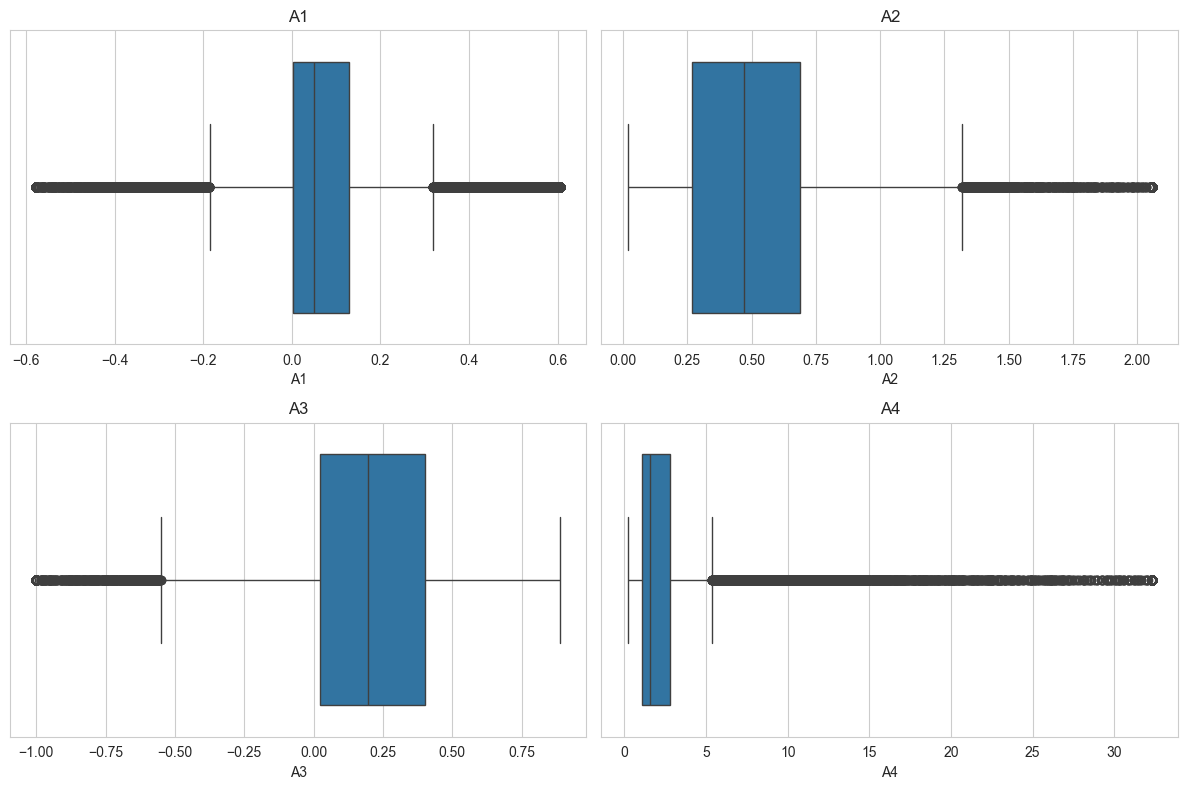

In [7]:
top_cols = [
    "A1",
    "A2",
    "A3",
    "A4"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for i, col in enumerate(top_cols):

    sns.boxplot(
        x=df_clean[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

# Feature Selection

In [8]:
X = df_clean.drop(
    columns=[
        "Bankrupt"
    ]
)

y = df_clean["Bankrupt"]

In [9]:
mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
})

mi_df = mi_df.sort_values(
    "MI Score",
    ascending=False
)

mi_df.head(20)

,Feature,MI Score
26,A27,0.027713
23,A24,0.015623
41,A42,0.014995
40,A41,0.014901
25,A26,0.014852
21,A22,0.014447
12,A13,0.014170
15,A16,0.013812
45,A46,0.013214
14,A15,0.013199


# Visualize Top Features

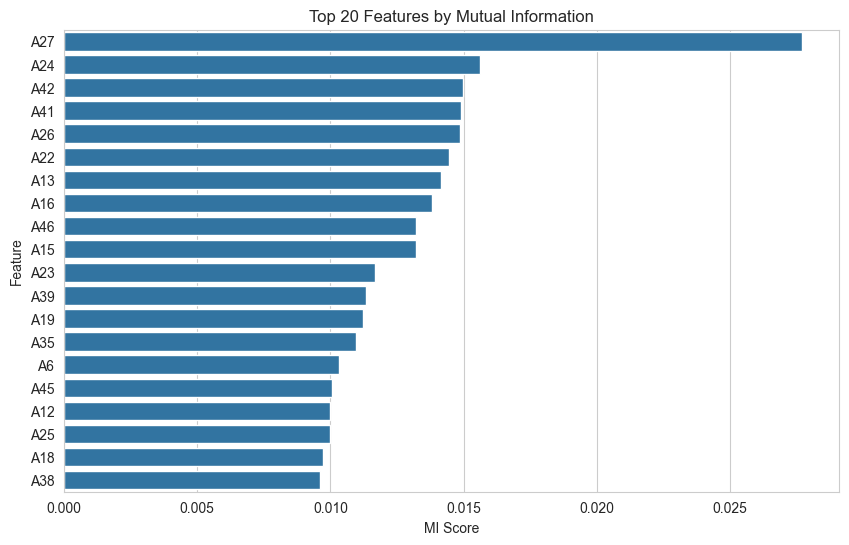

In [10]:
plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=mi_df.head(20),
    x="MI Score",
    y="Feature"
)

plt.title(
    "Top 20 Features by Mutual Information"
)

plt.show()

# Keep Top Features

In [11]:
selected_features = (
    mi_df
    .head(25)
    ["Feature"]
    .tolist()
)

selected_features.append(
    "Bankrupt"
)

df_final = df_clean[
    selected_features
]

In [12]:
print(
    "Original Shape:",
    df.shape
)

print(
    "Final Shape:",
    df_final.shape
)

Original Shape: (43405, 66)
Final Shape: (43405, 26)


# Save Processed Dataset

In [13]:
OUTPUT_PATH = "../data/bankruptcy_processed.csv"

df_final.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    f"Saved to {OUTPUT_PATH}"
)

Saved to ../data/bankruptcy_processed.csv


# Final Summary Cell

In [14]:
summary = pd.DataFrame({
    "Metric": [
        "Original Features",
        "Selected Features",
        "Rows",
        "Missing Values Remaining"
    ],
    "Value": [
        df.shape[1] - 1,
        len(selected_features) - 1,
        len(df_final),
        df_final.isnull().sum().sum()
    ]
})

summary

,Metric,Value
0,Original Features,65
1,Selected Features,25
2,Rows,43405
3,Missing Values Remaining,0
